In [99]:
from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV
import plotly.express as px
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 데이터셋 불러오기

In [100]:
cal_housing = datasets.fetch_california_housing()
X = pd.DataFrame(cal_housing.data, columns=cal_housing.feature_names)
y = pd.DataFrame(cal_housing.target, columns=['MedHouseVal'])

In [101]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [102]:
y.head()

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [103]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [104]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedHouseVal  20640 non-null  float64
dtypes: float64(1)
memory usage: 161.4 KB


# 데이터 탐색

In [105]:
raw_data = pd.concat([X, y], axis=1)
raw_data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


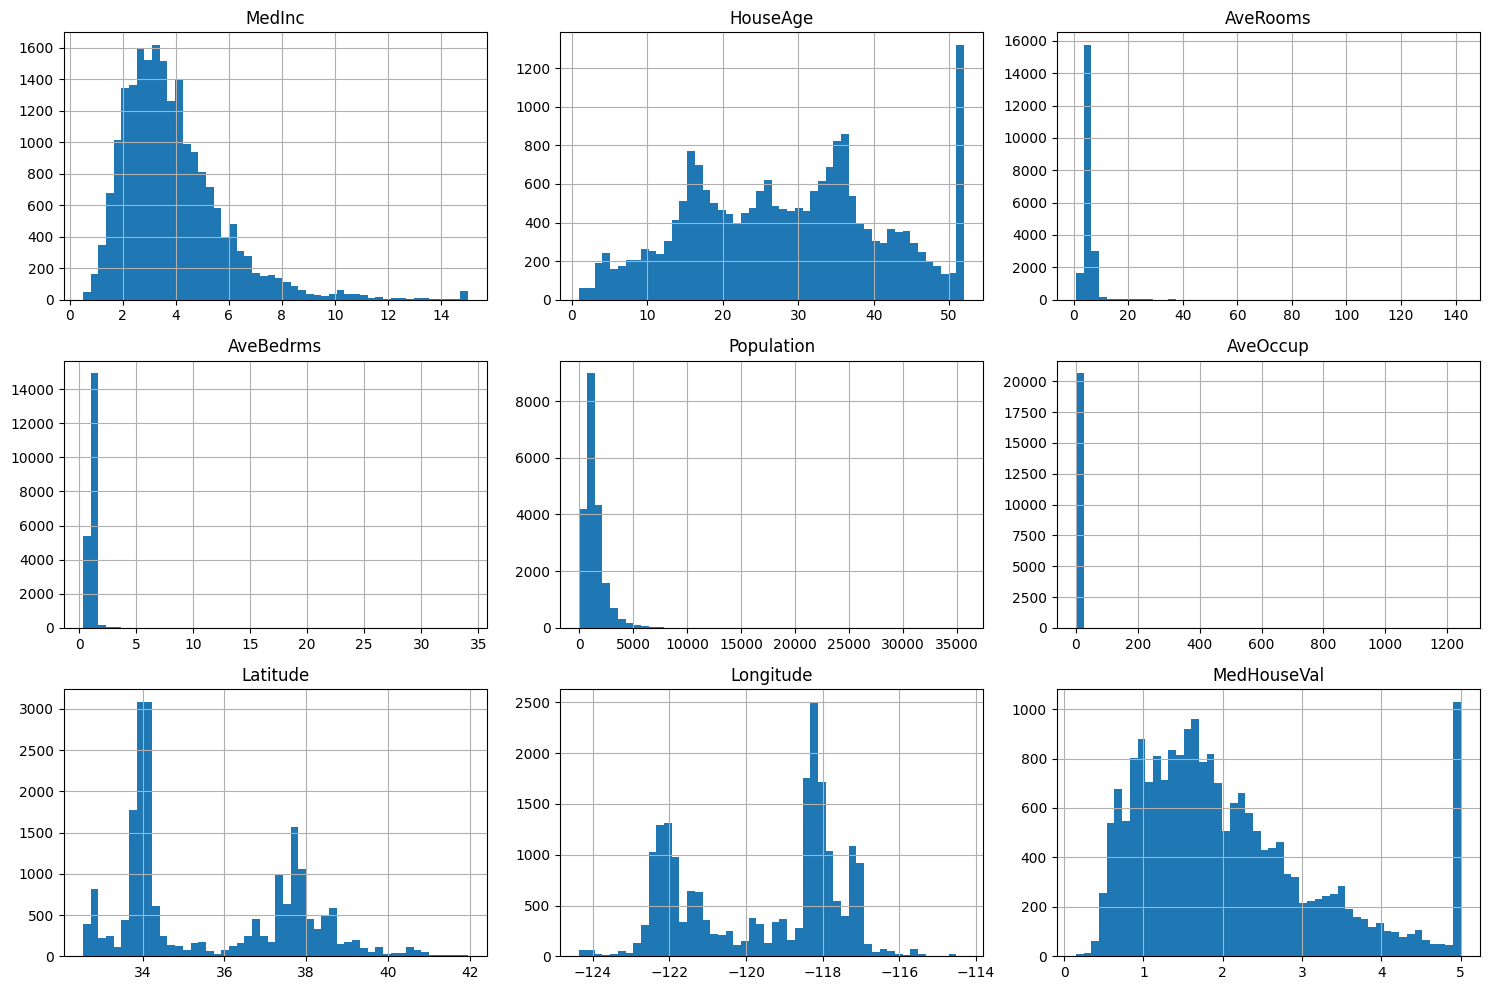

In [106]:
raw_data.hist(figsize=(15, 10), bins=50)
plt.tight_layout()
plt.show()

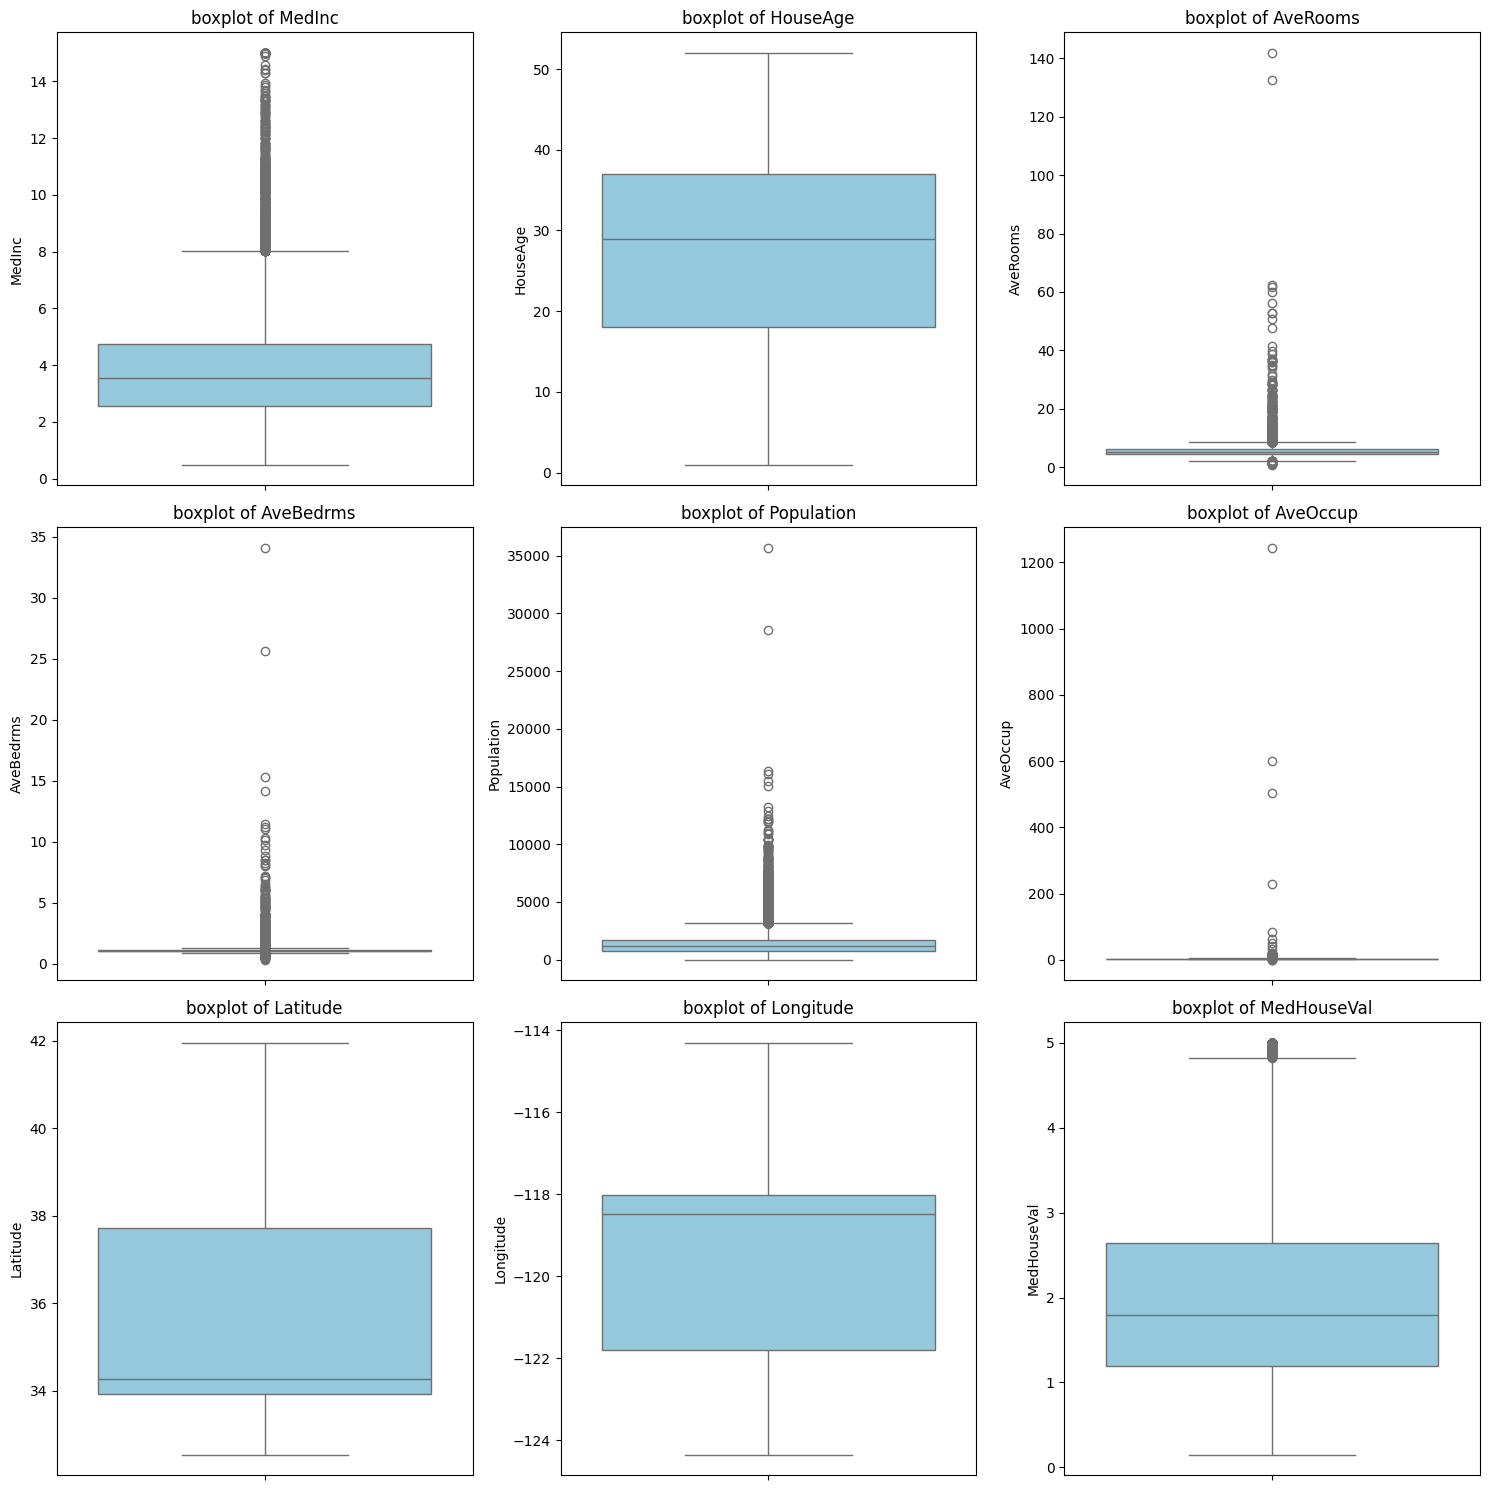

In [107]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(raw_data.columns):
    sns.boxplot(data=raw_data[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'boxplot of {col}')
plt.tight_layout()
plt.show()

`MedHouseVal` 변수에서 5.0 이상의 가격은 모두 5.00001로 기록됨.  
`HouseAge` 변수에서 52 이상의 값은 모두 52로 기록됨.  
`AveBedrms`의 값이 `AveRooms`의 값보다 큰 경우는 모순된 기록. 또한 값이 비현실적으로 클 경우 일반적 주거형태가 아니거나 이상치일 가능성 높음.  
`AveOccup` 변수에서 200 이상의 비현실적인 값 존재. 일반적인 주거 형태가 아닐 가능성 높음.


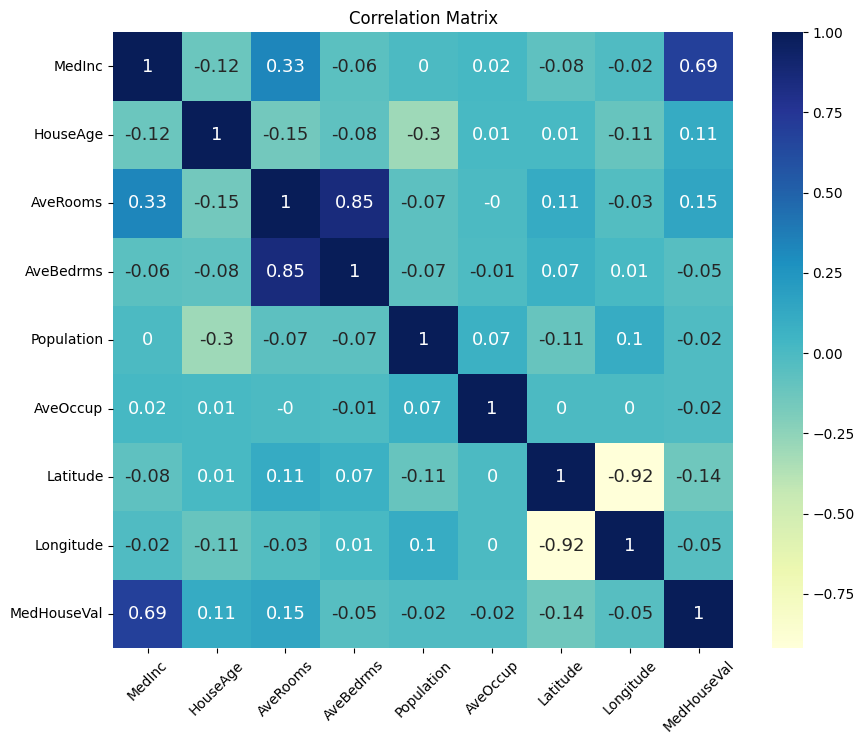

In [108]:
correlation_matrix = raw_data.corr().round(2)
plt.subplots(figsize=(10, 8))
sns.heatmap(data=correlation_matrix, annot=True, annot_kws={"size": 13}, cmap='YlGnBu')
plt.title('Correlation Matrix')
plt.xticks(rotation=45)
plt.show()

In [109]:
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["vif"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    return vif_data

calculate_vif(X)

,feature,vif
0,MedInc,11.511140
1,HouseAge,7.195917
2,AveRooms,45.993601
3,AveBedrms,43.590314
4,Population,2.935745
5,AveOccup,1.095243
6,Latitude,559.874071
7,Longitude,633.711654


In [110]:
fig = px.scatter_mapbox(raw_data,
                        lat='Latitude', lon='Longitude',
                        color='MedHouseVal', size='MedHouseVal',
                        zoom=5, height=1000, size_max=12,
                        title="california housing mapbox")
# fig.update_layout(mapbox_style='open-street-map')
fig.update_layout(mapbox_style='carto-positron')
fig.show()

위도가 경도가 작을수록 특히 서남부 해안선 근처로 갈수록 높은 가격의 집이 있음 <br>
또한 LA, 실리콘 밸리의 해안선 근처에 특히 높은 가격의 집들이 몰려있음을 확인할 수 잇음.  
이를 뒷받침할 수 있는 변수 생성이 필요해보임.

# 데이터 전처리

In [111]:
raw_data_clean = raw_data.copy()

In [112]:
raw_data_clean = raw_data_clean[
    (raw_data_clean['HouseAge'] < 52) &
    (raw_data_clean['MedHouseVal'] <= 5.0)
]

target_cols = ['AveRooms', 'AveOccup']
for col in target_cols:
    Q1 = raw_data_clean[col].quantile(0.25)
    Q3 = raw_data_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    raw_data_clean = raw_data_clean[(raw_data_clean[col] >= lower_bound) & (raw_data_clean[col] <= upper_bound)]

raw_data_clean = raw_data_clean[(raw_data_clean['AveBedrms'] <= raw_data_clean['AveRooms'])]
# raw_data_clean['Bedrms_Rooms_ratio'] = raw_data_clean['AveBedrms'] / raw_data_clean['AveRooms']
# raw_data_clean = raw_data_clean.drop('AveBedrms', axis=1)

raw_data_clean['lon_lat_mul'] = raw_data_clean['Longitude'] * raw_data_clean['Latitude']



In [113]:
# 주요 해안 도시 좌표 (위도, 경도)
coastal_cities = {
    'SF': (37.7749, -122.4194),
    'LA': (34.0522, -118.2437),
    'SD': (32.7157, -117.1611)
}

def get_min_distance_to_coast(lat, lon):
    distances = []
    for city_lat, city_lon in coastal_cities.values():
        dist = np.sqrt((lat - city_lat)**2 + (lon - city_lon)**2)
        distances.append(dist)
    return min(distances)

raw_data_clean['dist_to_coast'] = raw_data_clean.apply(lambda x: get_min_distance_to_coast(x['Latitude'], x['Longitude']), axis=1)

In [114]:
# 새로운 변수명 정의
feature_name = raw_data_clean.columns.tolist()
feature_name.remove('MedHouseVal')

In [115]:
print(raw_data_clean.shape)

(18285, 11)


In [116]:
X_clean = raw_data_clean.drop('MedHouseVal', axis=1)
y_clean = raw_data_clean['MedHouseVal']

# 데이터 탐색 (EDA)

In [117]:
raw_data_clean.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,lon_lat_mul,dist_to_coast
count,18285.000000,18285.000000,18285.000000,18285.000000,18285.000000,18285.000000,18285.000000,18285.000000,18285.000000,18285.000000,18285.000000
mean,3.694820,27.087503,5.238727,1.067737,1472.823517,2.945303,35.581301,-119.490344,1.900207,-4255.551863,0.809526
std,1.565047,11.419623,1.182308,0.135092,1126.569130,0.711385,2.141114,1.980714,0.959518,323.830786,0.811241
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.750000,32.540000,-124.300000,0.149990,-5207.673000,0.004305
25%,2.537000,18.000000,4.425121,1.005249,819.000000,2.471049,33.920000,-121.570000,1.154000,-4589.919000,0.209944
50%,3.470300,27.000000,5.196185,1.047452,1210.000000,2.856540,34.230000,-118.450000,1.719000,-4056.301600,0.488429
75%,4.625000,36.000000,5.965174,1.097113,1782.000000,3.314685,37.670000,-117.970000,2.440000,-4002.417900,1.200089
max,13.147700,51.000000,10.639456,3.411111,28566.000000,5.885870,41.950000,-114.550000,5.000000,-3753.968400,4.646915


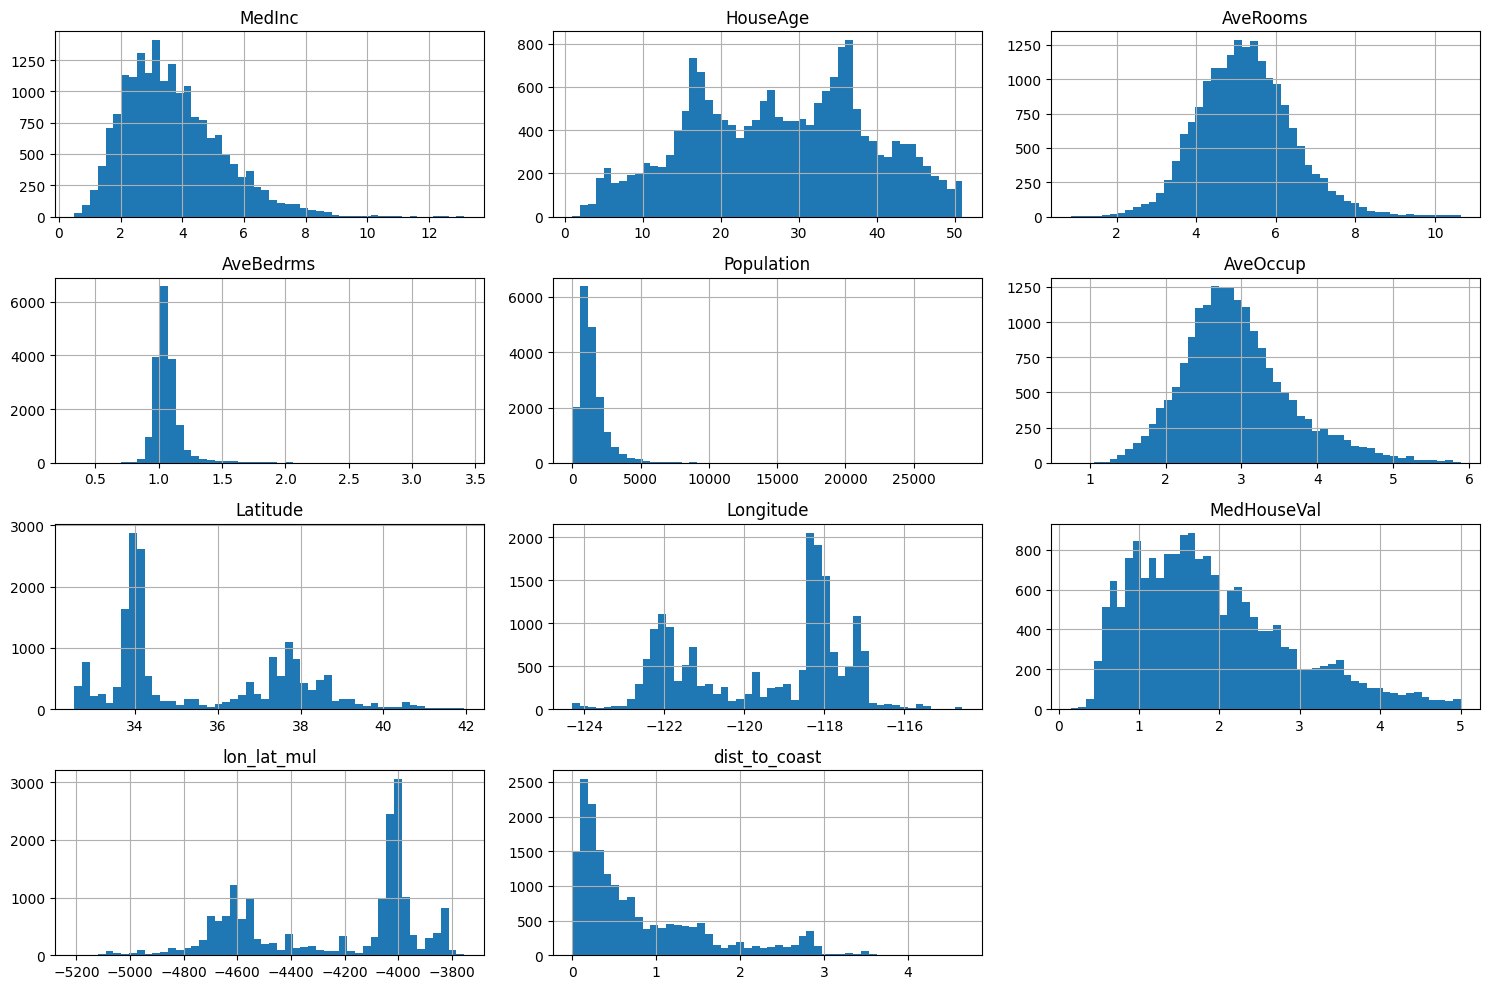

In [118]:
raw_data_clean.hist(figsize=(15, 10), bins=50)
plt.tight_layout()
plt.show()

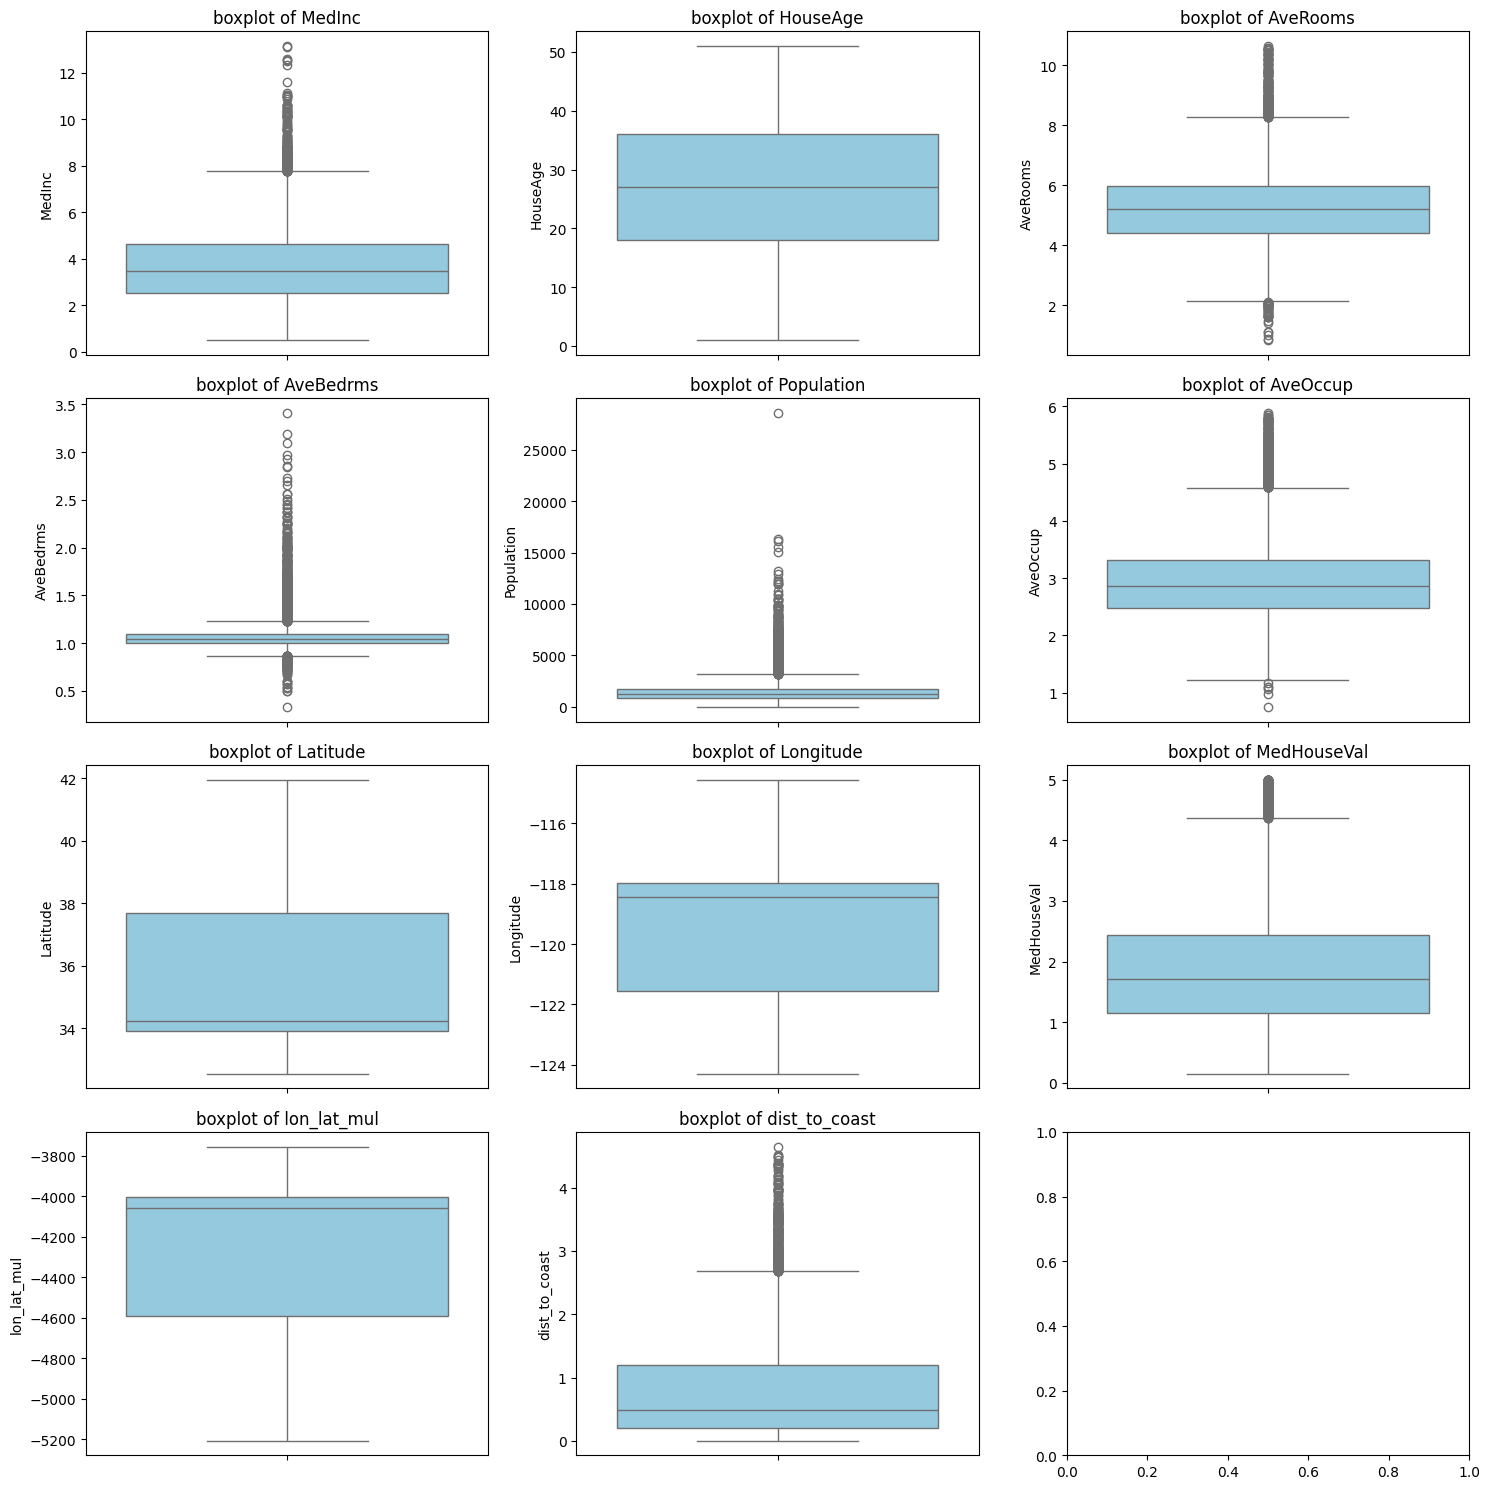

In [119]:
fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(raw_data_clean.columns):
    sns.boxplot(data=raw_data_clean[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'boxplot of {col}')
plt.tight_layout()
plt.show()

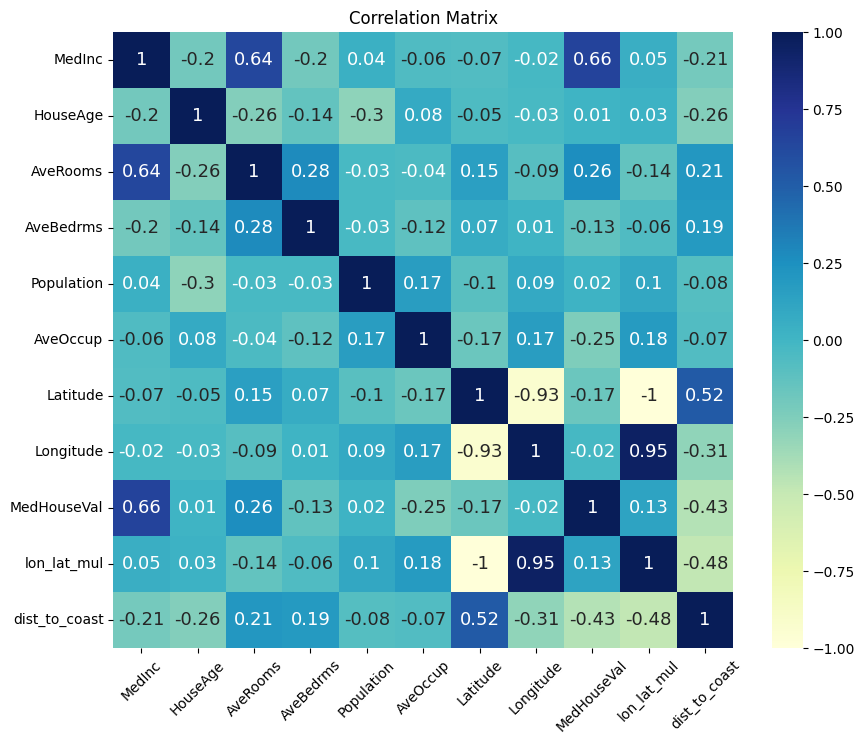

In [120]:
correlation_matrix = raw_data_clean.corr().round(2)
plt.subplots(figsize=(10, 8))
sns.heatmap(data=correlation_matrix, annot=True, annot_kws={"size": 13}, cmap='YlGnBu')
plt.title('Correlation Matrix')
plt.xticks(rotation=45)
plt.show()

In [121]:

calculate_vif(X_clean)

,feature,vif
0,MedInc,21.418495
1,HouseAge,9.168768
2,AveRooms,65.127245
3,AveBedrms,99.384253
4,Population,3.212748
5,AveOccup,20.146595
6,Latitude,40620.190466
7,Longitude,3868.045743
8,lon_lat_mul,20940.851472
9,dist_to_coast,4.444678


In [122]:
fig = px.scatter_mapbox(raw_data_clean,
                        lat='Latitude', lon='Longitude',
                        color='MedHouseVal', size='MedHouseVal',
                        zoom=5, height=1000, size_max=12,
                        title="california housing mapbox")
# fig.update_layout(mapbox_style='open-street-map')
fig.update_layout(mapbox_style='carto-positron')
fig.show()

# 데이터 변환

In [123]:
raw_data_clean1 = raw_data_clean.copy()

In [124]:
# 로그 변환 적용
log_cols = ['Population']

for col in log_cols:
    raw_data_clean1[col] = np.log1p(raw_data_clean1[col])

In [125]:
X_clean = raw_data_clean1.drop('MedHouseVal', axis=1)
y_clean = raw_data_clean1['MedHouseVal']

In [126]:
# 새로운 변수명 정의
feature_names = raw_data_clean1.columns.tolist()
feature_names.remove('MedHouseVal')

In [127]:
raw_data_clean1.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,lon_lat_mul,dist_to_coast
count,18285.000000,18285.000000,18285.000000,18285.000000,18285.000000,18285.000000,18285.000000,18285.000000,18285.000000,18285.000000,18285.000000
mean,3.694820,27.087503,5.238727,1.067737,7.071494,2.945303,35.581301,-119.490344,1.900207,-4255.551863,0.809526
std,1.565047,11.419623,1.182308,0.135092,0.706750,0.711385,2.141114,1.980714,0.959518,323.830786,0.811241
min,0.499900,1.000000,0.846154,0.333333,1.386294,0.750000,32.540000,-124.300000,0.149990,-5207.673000,0.004305
25%,2.537000,18.000000,4.425121,1.005249,6.709304,2.471049,33.920000,-121.570000,1.154000,-4589.919000,0.209944
50%,3.470300,27.000000,5.196185,1.047452,7.099202,2.856540,34.230000,-118.450000,1.719000,-4056.301600,0.488429
75%,4.625000,36.000000,5.965174,1.097113,7.486053,3.314685,37.670000,-117.970000,2.440000,-4002.417900,1.200089
max,13.147700,51.000000,10.639456,3.411111,10.260007,5.885870,41.950000,-114.550000,5.000000,-3753.968400,4.646915


In [128]:
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.30, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((12799, 10), (5486, 10), (12799,), (5486,))

박스플롯 결과 다수의 `이상치`가 발견되어 `RobustScaler`를 적용

In [129]:
robust_scaler = RobustScaler()

X_train_scaled = robust_scaler.fit_transform(X_train)
X_test_scaled = robust_scaler.transform(X_test)

# 다중선형회귀 `OLS`

In [130]:
ols_reg = LinearRegression()
ols_reg.fit(X_train_scaled, y_train)

print('Coefficients: ', ols_reg.coef_)
print('Intercept: ', ols_reg.intercept_)

Coefficients:  [ 0.85712513  0.09236694 -0.14748515  0.07762573  0.02346062 -0.25960326
  6.18315211 -3.21484832  9.53463557 -0.16626658]
Intercept:  1.9532894588585512


In [131]:
ols_df = pd.DataFrame(ols_reg.coef_, index=feature_names, columns=['coefficient'])
ols_df

,coefficient
MedInc,0.857125
HouseAge,0.092367
AveRooms,-0.147485
AveBedrms,0.077626
Population,0.023461
AveOccup,-0.259603
Latitude,6.183152
Longitude,-3.214848
lon_lat_mul,9.534636
dist_to_coast,-0.166267


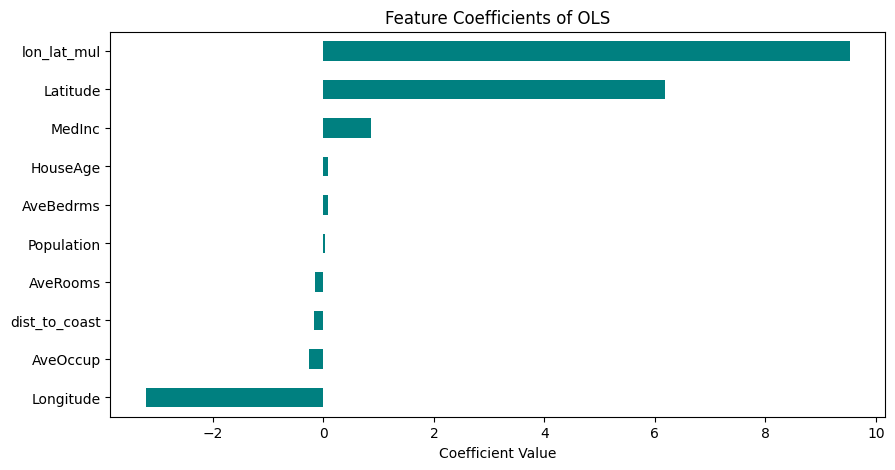

In [132]:
plt.figure(figsize=(10, 5))
series = pd.Series(ols_reg.coef_, index=feature_names).sort_values()
series.plot(kind='barh', color='teal')
plt.title(f'Feature Coefficients of OLS')
plt.xlabel('Coefficient Value')
plt.show()

In [133]:
y_pred_ols = ols_reg.predict(X_test_scaled)

In [134]:
print('MAE: ', round(mean_absolute_error(y_test, y_pred_ols),4))
print('MSE: ', round(mean_squared_error(y_test, y_pred_ols),4))
print('RMSE: ', round(root_mean_squared_error(y_test, y_pred_ols),4))
print('MAPE: ', round(mean_absolute_percentage_error(y_test, y_pred_ols),4))
print('R_Squared: ', round(r2_score(y_test, y_pred_ols),4))

MAE:  0.4275
MSE:  0.3333
RMSE:  0.5773
MAPE:  0.2718
R_Squared:  0.6416


<>:3: SyntaxWarning:

invalid escape sequence '\h'

<>:4: SyntaxWarning:

invalid escape sequence '\h'

<>:3: SyntaxWarning:

invalid escape sequence '\h'

<>:4: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipykernel_2115/28597392.py:3: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipykernel_2115/28597392.py:4: SyntaxWarning:

invalid escape sequence '\h'



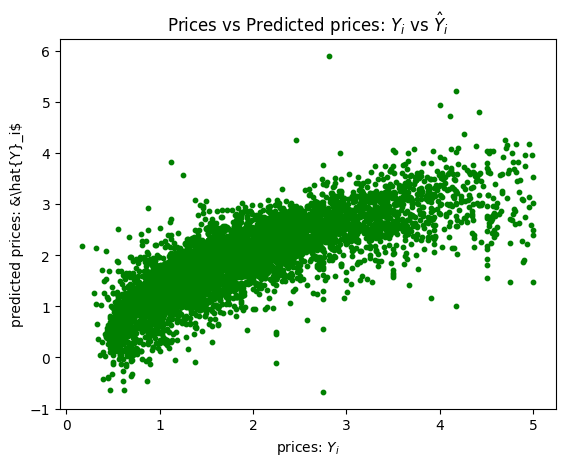

In [135]:
plt.scatter(y_test, y_pred_ols, s=10, c='green')
plt.xlabel('prices: $Y_i$')
plt.ylabel('predicted prices: &\hat{Y}_i$')
plt.title('Prices vs Predicted prices: $Y_i$ vs $\hat{Y}_i$')
plt.show()

# Ridge Regression

In [136]:
param_grid = {'alpha': np.arange(0.0001, 100, 0.5)}
ridge_grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train_scaled, y_train)

ridge_grid_pred = ridge_grid.predict(X_test_scaled)
ridge_grid_test_rmse = root_mean_squared_error(y_test, ridge_grid_pred)

In [137]:
ridge_best_model = ridge_grid.best_estimator_

y_train_pred = ridge_best_model.predict(X_train_scaled)
y_test_pred = ridge_best_model.predict(X_test_scaled)

def print_eval_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"[{dataset_name} Dataset에서의 성능]")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"R^2: {r2:.4f}")
    print("-" * 40)

print("=" * 50)
print(f"GridSearchCV 최적 Alpha: {ridge_grid.best_params_['alpha']:.4f}")
print(f"훈련 단계(5-Fold CV) 평균 RMSE: {-ridge_grid.best_score_:.4f}")
print(f"[최종 평가] GridSearchCV 모델의 Test RMSE: {ridge_grid_test_rmse:.4f}")
print("=" * 50)

print_eval_metrics(y_train, y_train_pred, "Train")
print_eval_metrics(y_test, y_test_pred, "Test")
print("=" * 50)

GridSearchCV 최적 Alpha: 0.0001
훈련 단계(5-Fold CV) 평균 RMSE: 0.3179
[최종 평가] GridSearchCV 모델의 Test RMSE: 0.5773
[Train Dataset에서의 성능]
RMSE: 0.5632
MAE: 0.4201
MSE: 0.3171
MAPE: 0.2703
R^2: 0.6540
----------------------------------------
[Test Dataset에서의 성능]
RMSE: 0.5773
MAE: 0.4275
MSE: 0.3333
MAPE: 0.2718
R^2: 0.6416
----------------------------------------


<Figure size 1000x500 with 0 Axes>

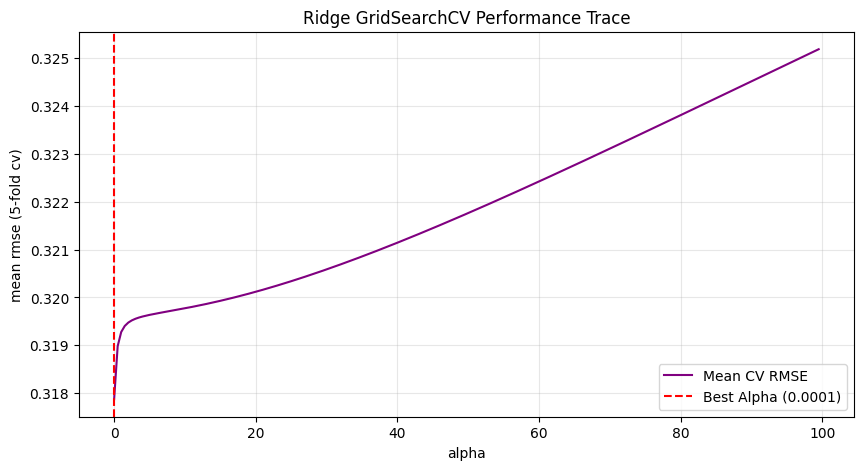

In [138]:
ridge_best_alpha_grid = ridge_grid.best_params_['alpha']

plt.figure(figsize=(10, 5))
cv_results_df = pd.DataFrame(ridge_grid.cv_results_)
plt.figure(figsize=(10, 5))
plt.plot(cv_results_df['param_alpha'], -cv_results_df['mean_test_score'], label='Mean CV RMSE', color='purple')
plt.axvline(ridge_best_alpha_grid, color='red', linestyle='--', label=f'Best Alpha ({ridge_best_alpha_grid})')
plt.title('Ridge GridSearchCV Performance Trace')
plt.xlabel('alpha')
plt.ylabel('mean rmse (5-fold cv)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

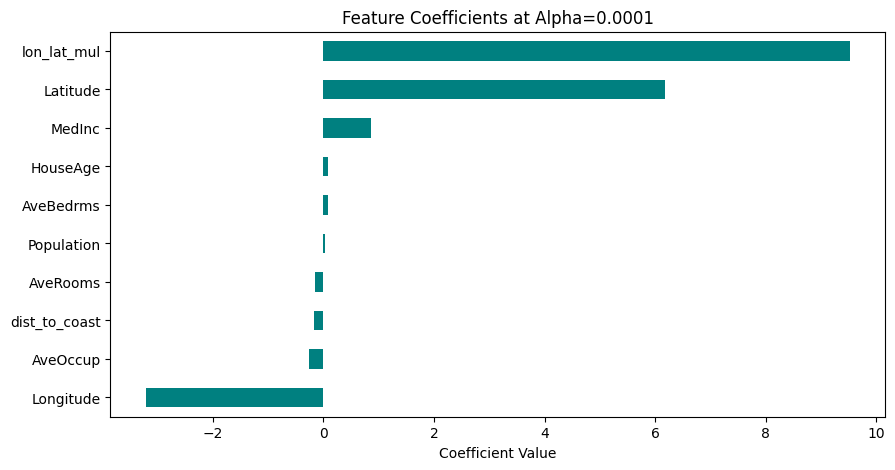

In [139]:
plt.figure(figsize=(10, 5))
series = pd.Series(ridge_best_model.coef_, index=feature_names).sort_values()
series.plot(kind='barh', color='teal')
plt.title(f'Feature Coefficients at Alpha={ridge_best_alpha_grid}')
plt.xlabel('Coefficient Value')
plt.show()

In [140]:
ridge_df = pd.DataFrame(ridge_best_model.coef_, index=feature_names, columns=['coefficient'])
ridge_df

,coefficient
MedInc,0.857131
HouseAge,0.092372
AveRooms,-0.147491
AveBedrms,0.077626
Population,0.023462
AveOccup,-0.259600
Latitude,6.179138
Longitude,-3.213733
lon_lat_mul,9.529439
dist_to_coast,-0.166256


# Lasso Regression

In [141]:
param_grid = {'alpha': np.arange(0.0001, 100, 0.5)}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), param_grid, cv=5, scoring='neg_root_mean_squared_error')
lasso_grid.fit(X_train_scaled, y_train)

lasso_grid_pred = lasso_grid.predict(X_test_scaled)
lasso_grid_test_rmse = root_mean_squared_error(y_test, lasso_grid_pred)

In [142]:
lasso_best_model = lasso_grid.best_estimator_

y_train_pred = lasso_best_model.predict(X_train_scaled)
y_test_pred = lasso_best_model.predict(X_test_scaled)

def print_eval_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"[{dataset_name} Dataset에서의 성능]")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"R^2: {r2:.4f}")
    print("-" * 40)

print("=" * 50)
print(f"GridSearchCV 최적 Alpha: {lasso_grid.best_params_['alpha']:.4f}")
print(f"훈련 단계(5-Fold CV) 평균 RMSE: {-lasso_grid.best_score_:.4f}")
print(f"[최종 평가] GridSearchCV 모델의 Test RMSE: {lasso_grid_test_rmse:.4f}")
print("=" * 50)

print_eval_metrics(y_train, y_train_pred, "Train")
print_eval_metrics(y_test, y_test_pred, "Test")
print("=" * 50)

GridSearchCV 최적 Alpha: 0.0001
훈련 단계(5-Fold CV) 평균 RMSE: 0.5649
[최종 평가] GridSearchCV 모델의 Test RMSE: 0.5788
[Train Dataset에서의 성능]
RMSE: 0.5644
MAE: 0.4204
MSE: 0.3186
MAPE: 0.2686
R^2: 0.6524
----------------------------------------
[Test Dataset에서의 성능]
RMSE: 0.5788
MAE: 0.4283
MSE: 0.3350
MAPE: 0.2706
R^2: 0.6397
----------------------------------------


<Figure size 1000x500 with 0 Axes>

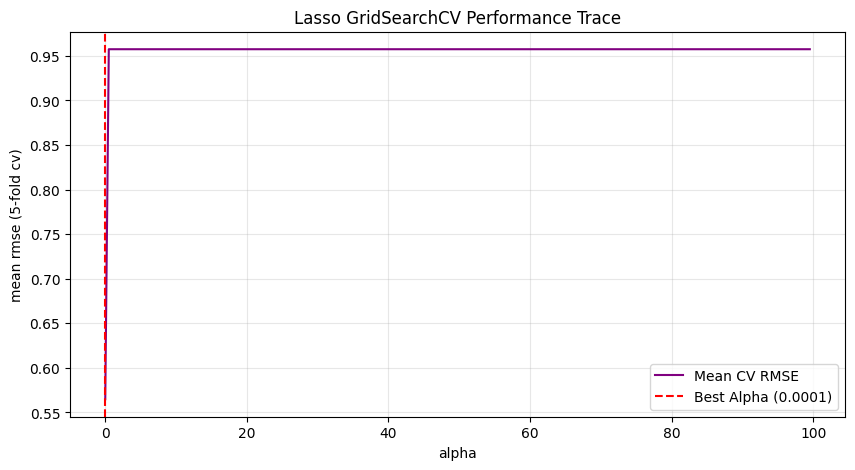

In [143]:
lasso_best_alpha_grid = lasso_grid.best_params_['alpha']

plt.figure(figsize=(10, 5))
cv_results_df = pd.DataFrame(lasso_grid.cv_results_)
plt.figure(figsize=(10, 5))
plt.plot(cv_results_df['param_alpha'], -cv_results_df['mean_test_score'], label='Mean CV RMSE', color='purple')
plt.axvline(lasso_best_alpha_grid, color='red', linestyle='--', label=f'Best Alpha ({lasso_best_alpha_grid})')
plt.title('Lasso GridSearchCV Performance Trace')
plt.xlabel('alpha')
plt.ylabel('mean rmse (5-fold cv)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<Figure size 1000x500 with 0 Axes>

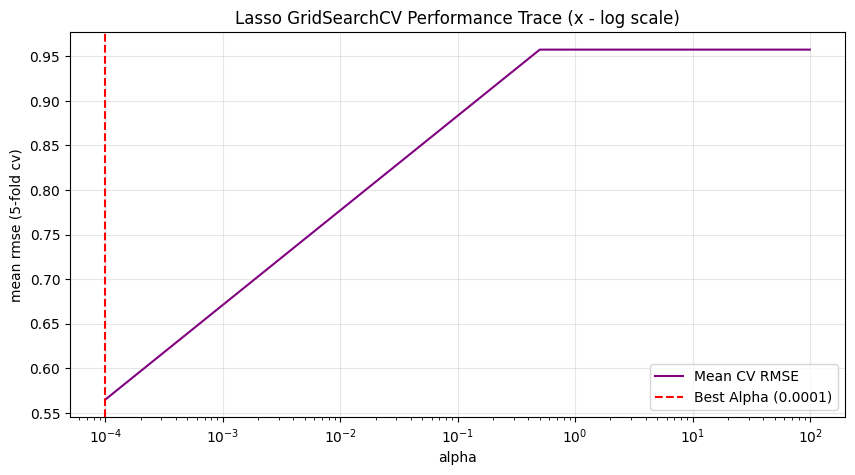

In [144]:
lasso_best_alpha_grid = lasso_grid.best_params_['alpha']

plt.figure(figsize=(10, 5))
cv_results_df = pd.DataFrame(lasso_grid.cv_results_)
plt.figure(figsize=(10, 5))
plt.plot(cv_results_df['param_alpha'], -cv_results_df['mean_test_score'], label='Mean CV RMSE', color='purple')
plt.axvline(lasso_best_alpha_grid, color='red', linestyle='--', label=f'Best Alpha ({lasso_best_alpha_grid})')
plt.title('Lasso GridSearchCV Performance Trace (x - log scale)')
plt.xlabel('alpha')
plt.ylabel('mean rmse (5-fold cv)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.show()

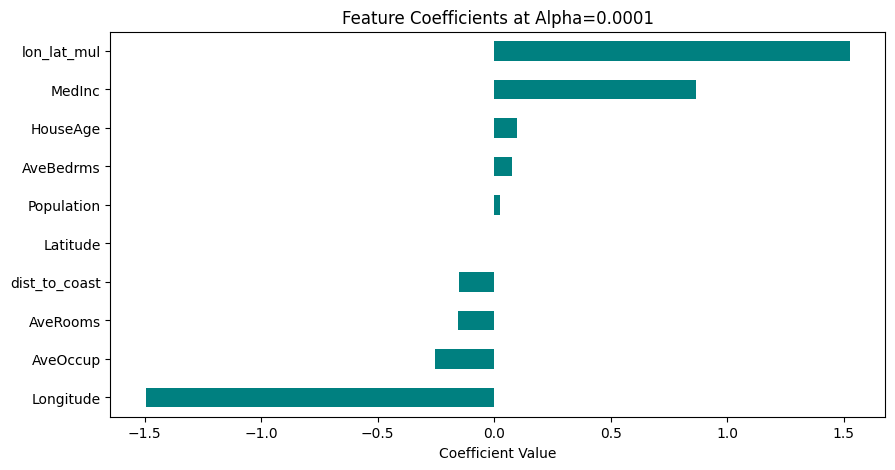

In [145]:
plt.figure(figsize=(10, 5))
series = pd.Series(lasso_best_model.coef_, index=feature_names).sort_values()
series.plot(kind='barh', color='teal')
plt.title(f'Feature Coefficients at Alpha={lasso_best_alpha_grid}')
plt.xlabel('Coefficient Value')
plt.show()

In [146]:
lasso_df = pd.DataFrame(lasso_best_model.coef_, index=feature_names, columns=['coefficient'])
lasso_df

,coefficient
MedInc,0.865924
HouseAge,0.099107
AveRooms,-0.155025
AveBedrms,0.077794
Population,0.024659
AveOccup,-0.254582
Latitude,0.000000
Longitude,-1.495193
lon_lat_mul,1.528402
dist_to_coast,-0.150092
